## Работа с API на Python
API (англ. application programming interface — программный интерфейс приложения) — это интерфейс прикладного программирования. Благодаря ему разные программы, приложения и в принципе любые виды программного обеспечения взаимодействуют друг с другом — передают и получают данные по запросу. API выполняет роль посредника и делает возможным их совместную работу. 

**Определение**  

По сути API  — это набор способов и правил, по которым различные программы общаются между собой и обмениваются данными.

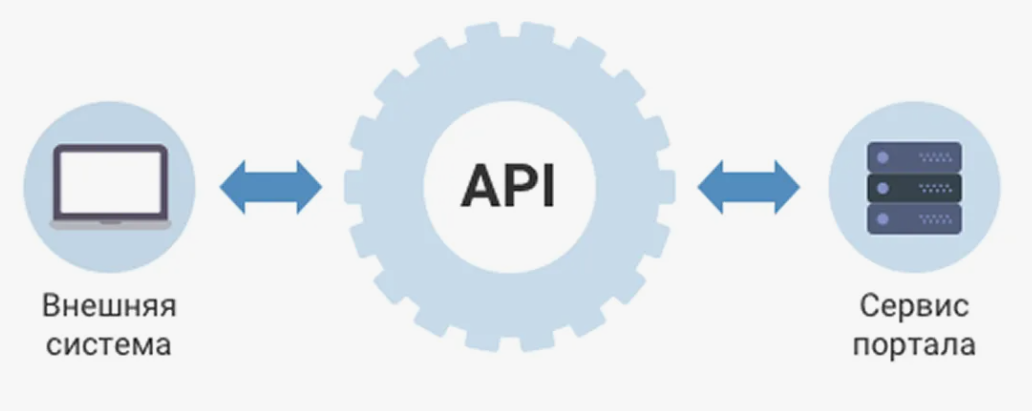

Программный интерфейс похож на договор между клиентом и продавцом. Только клиентом выступает приложение, которому нужны данные, а продавцом — сервер или ресурс, с которого мы эти данные берём. В таком договоре прописываются условия того, как и какие данные может получить клиент.

С помощью вызовов API можно выполнить определённые функции программы, не зная, как она работает. Поэтому API и называют интерфейсом.

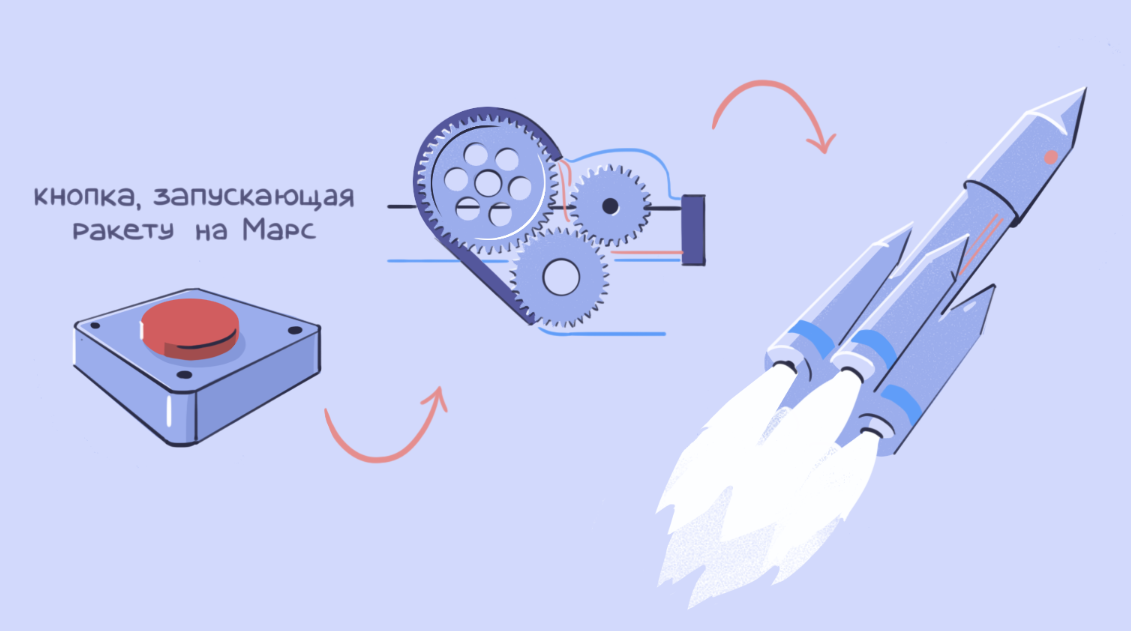

### Виды API
Для разных проектов нужны разные API, ведь в одних ситуациях важна скорость работы, а в других — надёжность и совместимость с определённой экосистемой.

Web API — общее название для всех API, которые используют для взаимодействия между веб-сервисами через интернет. С их помощью приложения обмениваются данными и выполняют действия по протоколу HTTP(S). Все перечисленные ниже интерфейсы относятся к Web API.


#### REST
REST (Representational State Transfer) API — это архитектурный подход для создания веб-сервисов. Он прописывает ограничения устройства и функциональности API. По сути, REST — это набор правил и принципов. Всего их шесть:
* **Клиент-серверная архитектура**. При этом подходе приложение состоит из двух «ипостастей»: сервера и клиента. Например, код и ресурсы этой страницы хранятся на серверах ИТМО, а ваш браузер выступает в роли клиента, который подтягивает с сервера нужные вам данные.

* **Отсутствие состояния (statelessness)**. Сервер не хранит данные о предыдущих взаимодействиях с клиентом — каждый запрос от клиента к серверу должен быть самодостаточным. При таком подходе нагрузка на сервер снижается в несколько раз — ему не нужно держать в памяти каждую сессию обмена данными с клиентом.

* **Кэшируемость (cacheability)**. Благодаря кэшируемости клиент может сохранять ответы API для повторного использования без выполнения запроса. Это снижает задержку и нагрузку на сервер. Ответы REST API также должны указывать, могут ли они быть кэшированы клиентом.

* **Единообразие интерфейса** (uniform interface). REST API должны работать через единообразный интерфейс, который упрощает взаимодействие между клиентами и серверами. В REST API это стандартные методы HTTP (*GET, POST, PUT, DELETE*), а также чёткие соглашения об именовании ресурсов.

* **Cлои (layered system)**. Архитектура REST API — это настоящий слоёный пирог, который состоит из серверов, прокси, шлюзов, балансировщиков нагрузки и массы других вспомогательных систем. Поэтому клиенты никогда не знают точно, общаются они напрямую с сервером или с его «дублёром».

    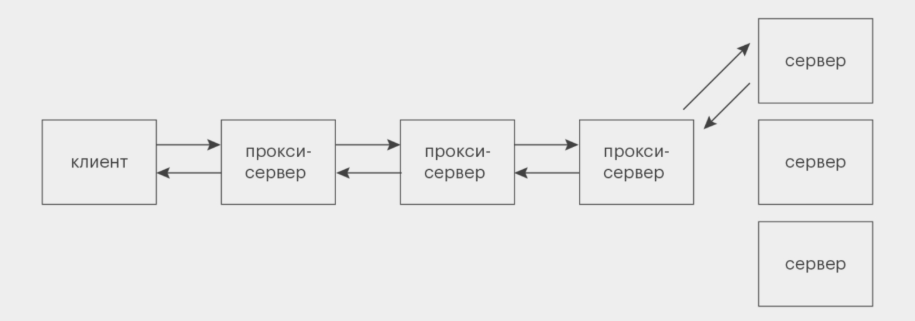  

* **Код по требованию (code on demand)** — необязательный принцип. Сервер может отправлять код, который будет выполняться уже на стороне клиента, — например, это может быть код JS-скриптов и других интерактивных элементов интерфейса.

    **Плюсы REST API**

* Освоить проще, чем *SOAP* или *GraphQL*.
* Используются стандартные HTTP-методы (*GET, POST, PUT, DELETE*).
* Широкая поддержка и совместимость с веб-технологиями.
* Кэширование и масштабируемость.

Пример REST API для сервиса управления книгами

In [ ]:
GET /api/books HTTP/1.1
Host: library.example.com
Accept: application/json

Ответ сервера (статус 200 OK):

In [ ]:
[
  {
    "id": 1,
    "title": "Мастер и Маргарита",
    "author": "Михаил Булгаков",
    "year": 1966,
    "available": true
  },
  {
    "id": 2,
    "title": "1984",
    "author": "Джордж Оруэлл",
    "year": 1949,
    "available": false
  }
]


**Основные HTTP‑методы в REST**

* *GET* — получить данные ресурса.

* *POST* — создать новый ресурс.

* *PUT / PATCH* — обновить существующий ресурс (*PUT* — полная замена, *PATCH* — частичное обновление).

* *DELETE* — удалить ресурс.

[UrbanAPI](http://10.32.1.107:5300/api/docs#/)

#### SOAP
SOAP (Simple Object Access Protocol) — строгий протокол обмена сообщениями по сети. Для форматирования сообщений используется язык разметки XML, а правила описания, обработки и передачи сообщений жёстко стандартизированы. Одна из главных отличительных черт SOAP — высокий уровень безопасности, который обеспечивается механизмами шифрования, аутентификации сообщений и управления транзакциями.

    **Плюсы SOAP API**

* Стандартизация. SOAP — стандартизированный протокол с чёткими правилами для обмена сообщениями. Это позволяет всегда получать предсказуемый результат.

* Безопасность. Поддерживаются методы шифрования и управления транзакциями, а сообщения можно подписывать цифровой подписью, что полезно для корпоративных приложений.

* Гибкость. SOAP работает поверх различных протоколов передачи данных, включая HTTP, TCP и SMTP, в отличие от, например, REST API, который использует только HTTP.

Пример SOAP‑запроса (получение курса USD):

In [ ]:
<soapenv:Envelope xmlns:soapenv="http://www.w3.org/2003/05/soap-envelope"
                xmlns:cur="http://bank.example.ru/currency">
   <soapenv:Header>
      <cur:AuthHeader>
         <cur:Username>api_user</cur:Username>
         <cur:Password>password</cur:Password>
      </cur:AuthHeader>
   </soapenv:Header>
   <soapenv:Body>
      <cur:GetExchangeRate>
         <cur:Currency>USD</cur:Currency>
         <cur:Date>2025-10-17</cur:Date>
      </cur:GetExchangeRate>
   </soapenv:Body>
</soapenv:Envelope>

[Ссылка на API Центрабанка РФ](https://www.cbr.ru/development/SXML/)

**Принцип работы**

1. Клиент формирует XML‑сообщение по правилам SOAP и отправляет его на SOAP‑эндпоинт (URL сервиса).

2. Сервер получает запрос, проверяет структуру Envelope и содержимое Header (аутентификация и т. д.).

3. Сервер обрабатывает данные из Body согласно своей бизнес‑логике.

4. Сервер формирует SOAP‑ответ (с данными или ошибкой Fault) и отправляет клиенту.

5. Клиент анализирует ответ, извлекает нужные данные из Body.

#### GraphQL
GraphQL — это язык запросов для API. Он хорош тем, что позволяет клиентам запрашивать только данные, которые им действительно нужны. Кроме того, с помощью одного запроса GraphQL можно получить данные, которые в REST требовали бы двух или даже трёх запросов подряд. Такая работа API возможна благодаря строгой типизации структуры запросов.

**Плюсы GraphQL**

* Гибкость. Клиенты могут запрашивать только нужные данные, что позволяет избегать передачи лишней информации.

* Агрегация данных. С помощью одного запроса можно получить данные сразу из нескольких источников. При использовании других видов API для этого потребовалось бы последовательно выполнить несколько запросов.

* Эффективность. По сети не передаются лишние данные, а это снижает нагрузку на сервер и экономит ресурсы сети.

Пример: API для блога

Представим сервис с пользователями, постами и комментариями.

**Шаг 1**. Схема данных (SDL)
Описываем типы и запросы на языке Schema Definition Language (SDL):

In [ ]:
type User {
  id: ID!
  name: String!
  email: String!
  posts: [Post!]!
}

type Post {
  id: ID!
  title: String!
  content: String
  author: User!
  comments: [Comment!]!
}

type Comment {
  id: ID!
  text: String!
  author: User!
  post: Post!
}

type Query {
  users: [User!]!
  user(id: ID!): User
  posts: [Post!]!
  post(id: ID!): Post
}


Пояснения к синтаксису:

* *ID!, String!* — обязательные поля (! означает *Non‑Null*).

* *[Post!]!* — массив обязательных объектов Post.

* *type Query* — корневые запросы для чтения данных.

**Шаг 2**. Получить список пользователей с их постами

In [ ]:
query {
  users {
    id
    name
    posts {
      title
    }
  }
}


Ответ сервера (JSON):

In [ ]:
{
  "data": {
    "users": [
      {
        "id": "1",
        "name": "Анна",
        "posts": [
          { "title": "Мой первый пост" },
          { "title": "Путешествие в горы" }
        ]
      },
      {
        "id": "2",
        "name": "Иван",
        "posts": [
          { "title": "Введение в GraphQL" }
        ]
      }
    ]
  }
}


###  Рaбота с модулем *request*
Модуль *requests* — одна из самых популярных библиотек Python для выполнения HTTP‑запросов. Он упрощает взаимодействие с веб‑сервисами и API, делая код читаемым и лаконичным.

Преимущества requests перед стандартными модулями:

* простой и понятный синтаксис;

* автоматическая обработка JSON;

* поддержка сессий;

* удобная работа с заголовками и параметрами;

* обработка исключений.


In [ ]:
import requests

# Отправляем GET‑запрос к API ЦБ РФ
url = 'https://www.cbr.ru/scripts/XML_daily.asp'
response = requests.get(url)


Статус ответа: 200
Заголовки: application/xml; charset=windows-1251


In [8]:
response.content

b'<?xml version="1.0" encoding="windows-1251"?><ValCurs Date="28.02.2026" name="Foreign Currency Market"><Valute ID="R01010"><NumCode>036</NumCode><CharCode>AUD</CharCode><Nominal>1</Nominal><Name>\xc0\xe2\xf1\xf2\xf0\xe0\xeb\xe8\xe9\xf1\xea\xe8\xe9 \xe4\xee\xeb\xeb\xe0\xf0</Name><Value>55,0652</Value><VunitRate>55,0652</VunitRate></Valute><Valute ID="R01020A"><NumCode>944</NumCode><CharCode>AZN</CharCode><Nominal>1</Nominal><Name>\xc0\xe7\xe5\xf0\xe1\xe0\xe9\xe4\xe6\xe0\xed\xf1\xea\xe8\xe9 \xec\xe0\xed\xe0\xf2</Name><Value>45,4551</Value><VunitRate>45,4551</VunitRate></Valute><Valute ID="R01030"><NumCode>012</NumCode><CharCode>DZD</CharCode><Nominal>100</Nominal><Name>\xc0\xeb\xe6\xe8\xf0\xf1\xea\xe8\xf5 \xe4\xe8\xed\xe0\xf0\xee\xe2</Name><Value>59,5434</Value><VunitRate>0,595434</VunitRate></Valute><Valute ID="R01035"><NumCode>826</NumCode><CharCode>GBP</CharCode><Nominal>1</Nominal><Name>\xd4\xf3\xed\xf2 \xf1\xf2\xe5\xf0\xeb\xe8\xed\xe3\xee\xe2</Name><Value>104,4353</Value><VunitRat

In [9]:
# Проверяем статус ответа
print(f"Статус ответа: {response.status_code}")
print(f"Заголовки: {response.headers['Content-Type']}")

Статус ответа: 200
Заголовки: application/xml; charset=windows-1251


In [10]:
# Обработка XML‑ответа
import xmltodict

url = 'https://www.cbr.ru/scripts/XML_daily.asp'
response = requests.get(url)
response.raise_for_status()  # Вызывает исключение при ошибке HTTP

# Преобразуем XML в словарь Python
data = xmltodict.parse(response.content)
data


{'ValCurs': {'@Date': '28.02.2026',
  '@name': 'Foreign Currency Market',
  'Valute': [{'@ID': 'R01010',
    'NumCode': '036',
    'CharCode': 'AUD',
    'Nominal': '1',
    'Name': 'Австралийский доллар',
    'Value': '55,0652',
    'VunitRate': '55,0652'},
   {'@ID': 'R01020A',
    'NumCode': '944',
    'CharCode': 'AZN',
    'Nominal': '1',
    'Name': 'Азербайджанский манат',
    'Value': '45,4551',
    'VunitRate': '45,4551'},
   {'@ID': 'R01030',
    'NumCode': '012',
    'CharCode': 'DZD',
    'Nominal': '100',
    'Name': 'Алжирских динаров',
    'Value': '59,5434',
    'VunitRate': '0,595434'},
   {'@ID': 'R01035',
    'NumCode': '826',
    'CharCode': 'GBP',
    'Nominal': '1',
    'Name': 'Фунт стерлингов',
    'Value': '104,4353',
    'VunitRate': '104,4353'},
   {'@ID': 'R01060',
    'NumCode': '051',
    'CharCode': 'AMD',
    'Nominal': '100',
    'Name': 'Армянских драмов',
    'Value': '20,4970',
    'VunitRate': '0,20497'},
   {'@ID': 'R01080',
    'NumCode': '048',
 

In [ ]:
print("Дата курсов:", data['ValCurs']['@Date'])

Дата курсов: 28.02.2026


In [15]:
# пишем функцию для извлечение курса USD
def get_usd_rate(data_dict):
    """Извлекает курс USD из данных ЦБ РФ"""
    for valute in data_dict['ValCurs']['Valute']:
        if valute['CharCode'] == 'USD':
            # Заменяем запятую на точку и преобразуем в float
            return float(valute['Value'].replace(',', '.'))
    return None

In [16]:
# Используем функцию для извлечение курса USD
usd_rate = get_usd_rate(data)
if usd_rate:
    print(f"Курс USD: {usd_rate:.2f} руб.")
else:
    print("USD не найден в списке валют")


Курс USD: 77.27 руб.


In [19]:
# полный код скрипта для получения данных о курсе доллара с проверкой
import requests
import xmltodict

def fetch_cbr_rates():
    """Получает курсы валют с сайта ЦБ РФ"""
    url = 'https://www.cbr.ru/scripts/XML_daily.asp'

    try:
        # Отправляем запрос с таймаутом 10 секунд
        response = requests.get(url, timeout=10)
        response.raise_for_status()  # Проверка HTTP‑статуса

        # Парсим XML
        data = xmltodict.parse(response.content)
        return data

    except requests.exceptions.RequestException as e:
        print(f"Ошибка при запросе к API: {e}")
        return None
    except xmltodict.expat.ExpatError as e:
        print(f"Ошибка парсинга XML: {e}")
        return None

def get_currency_rate(data, currency_code):
    """Возвращает курс указанной валюты"""
    if not data:
        return None

    for valute in data['ValCurs']['Valute']:
        if valute['CharCode'] == currency_code:
            return float(valute['Value'].replace(',', '.'))
    return None

# Получаем данные
cbr_data = fetch_cbr_rates()

# Извлекаем курсы
usd = get_currency_rate(cbr_data, 'USD')
eur = get_currency_rate(cbr_data, 'EUR')

if usd:
    print(f"Курс USD: {usd:.2f} руб.")
if eur:
    print(f"Курс EUR: {eur:.2f} руб.")


Курс USD: 77.27 руб.
Курс EUR: 91.30 руб.


[httpbin.org](https://httpbin.org/) — это бесплатный онлайн‑сервис для тестирования и отладки HTTP‑запросов и клиентов. Сервис «эхо‑отвечает»: он возвращает информацию о вашем запросе в структурированном виде (обычно JSON).

#### Основные методы модуля requests

1. GET‑запросы

In [22]:
# Простой запрос
response = requests.get('https://httpbin.org/get')
print(response)

# С параметрами
params = {'key1': 'value1', 'key2': 'value2'}
response = requests.get('https://httpbin.org/get', params=params)
print(response)

# С заголовками
headers = {'User-Agent': 'MyApp/1.0'}
response = requests.get('https://httpbin.org/get', headers=headers)
print(response)


<Response [200]>
<Response [200]>
<Response [200]>


2. POST‑запросы

In [23]:
# Отправка данных в формате form
data = {'username': 'user', 'password': 'pass'}
response = requests.post('https://httpbin.org/post', data=data)
print(response)

# Отправка JSON
json_data = {'name': 'John', 'age': 30}
response = requests.post('https://httpbin.org/post', json=json_data)
print(response)

<Response [200]>
<Response [200]>


3. PUT-запросы

In [28]:
url = 'https://httpbin.org/put'
data = {
    'name': 'Alice',
    'email': 'alice@example.com',
    'status': 'active'
}

response = requests.put(url, json=data)
print(response)

# Выводим ответ сервера
result = response.json()
print("Ответ сервера:")
result



<Response [200]>
Ответ сервера:


{'args': {},
 'data': '{"name": "Alice", "email": "alice@example.com", "status": "active"}',
 'files': {},
 'form': {},
 'headers': {'Accept': '*/*',
  'Accept-Encoding': 'gzip, deflate',
  'Content-Length': '67',
  'Content-Type': 'application/json',
  'Host': 'httpbin.org',
  'User-Agent': 'python-requests/2.32.3',
  'X-Amzn-Trace-Id': 'Root=1-69a58983-0e4927d66f75712c03aa16d5'},
 'json': {'email': 'alice@example.com', 'name': 'Alice', 'status': 'active'},
 'origin': '77.234.210.172',
 'url': 'https://httpbin.org/put'}

In [ ]:
print(f"URL: {result['url']}")
print(f"Данные: {result['json']}")

4. DELETE-запрос

In [ ]:
# Удаляем пользователя с ID 123
user_id = 123
url = f'https://httpbin.org/delete?user_id={user_id}'

response = requests.delete(url)

print(f"Запрос на удаление пользователя {user_id}")
print(f"Статус ответа: {response.status_code}")

# В реальном API здесь мог бы быть ответ о результате удаления
if response.status_code in [200, 204]:
    print("Ресурс успешно удалён!")
else:
    print("Ошибка при удалении")


Запрос на удаление пользователя 123
Статус ответа: 200
Ресурс успешно удалён!


#### Обработка ошибок и исключений


In [30]:
try:
    response = requests.get('https://example.com', timeout=5)
    response.raise_for_status()
except requests.exceptions.Timeout:
    print("Превышено время ожидания")
except requests.exceptions.ConnectionError:
    print("Ошибка подключения к серверу")
except requests.exceptions.HTTPError as e:
    print(f"HTTP ошибка: {e}")
except requests.exceptions.RequestException as e:
    print(f"Общая ошибка запроса: {e}")


##### Полезные атрибуты объекта Response

In [ ]:
response = requests.get('https://httpbin.org/get')

print(response.status_code)   # 200
print(response.text)          # Текст ответа (строка)
print(response.headers)       # Заголовки ответа, метаинформация, которую сервер отправляет вместе с основным содержимым ответа
print(type(response.content)) # Бинарные данные
print(response.json())        # JSON‑данные (если применимо)

200
{
  "args": {}, 
  "headers": {
    "Accept": "*/*", 
    "Accept-Encoding": "gzip, deflate", 
    "Host": "httpbin.org", 
    "User-Agent": "python-requests/2.32.3", 
    "X-Amzn-Trace-Id": "Root=1-69a58cbc-02fda5a502d340202523b88f"
  }, 
  "origin": "77.234.210.172", 
  "url": "https://httpbin.org/get"
}

{'Date': 'Mon, 02 Mar 2026 13:12:29 GMT', 'Content-Type': 'application/json', 'Content-Length': '308', 'Connection': 'keep-alive', 'Server': 'gunicorn/19.9.0', 'Access-Control-Allow-Origin': '*', 'Access-Control-Allow-Credentials': 'true'}
<class 'bytes'>
{'args': {}, 'headers': {'Accept': '*/*', 'Accept-Encoding': 'gzip, deflate', 'Host': 'httpbin.org', 'User-Agent': 'python-requests/2.32.3', 'X-Amzn-Trace-Id': 'Root=1-69a58cbc-02fda5a502d340202523b88f'}, 'origin': '77.234.210.172', 'url': 'https://httpbin.org/get'}


**Рекомендации**
1. Всегда используйте таймаут (timeout) — иначе запрос может висеть бесконечно.

2. Проверяйте статус ответа через raise_for_status() или проверку кода.

3. Обрабатывайте исключения — сеть может быть нестабильной.

4. Используйте сессии для серии запросов к одному домену.

5. Кэшируйте ответы, если данные меняются нечасто (курсы валют обновляются раз в день).

6. Соблюдайте лимиты API — не делайте частые запросы.

#### Как парсить с веб-сервисов с открытыми данными?
Веб-сервисы с открытыми данными обычно предоставляют документацию, где описан порядок их получения, включая подключение к API. 

Проиллюстрируем это на примере системы цифрового картографирования почв [Soilgrids](soilgrids.orghttps://soilgrids.org/), которая основана на глобальной базе данных почвенных профилей и экологических слоях. 

Чтобы правильно написать запрос необходимо изучить [документацию](https://docs.isric.org/globaldata/soilgrids/) сервиса.

In [ ]:
# Проверка соединения с API (читаем справку в Tutorials/WCS/GetCapabilities)
def test_connection():
    """Проверяет соединение с сервером SoilGrids"""
    test_url = "http://maps.isric.org/mapserv?map=/map/clay.map&service=WCS&version=1.0.0&request=GetCapabilities"
    try:
        response = requests.get(test_url, timeout=30)
        if response.status_code == 200:
            print("Соединение с SoilGrids установлено")
        else:
            print(f"Ошибка соединения: HTTP {response.status_code}")
            return False
    except Exception as e:
        print(f"Ошибка соединения: {e}")
    
test_connection()

Соединение с SoilGrids установлено
